# 05. Анализ аномалий временного ряда

Сравнение 3 методов выявления аномалий во временном ряду.

Используются:

- rolling z-score;
- STL residual anomalies;
- IsolationForest.

Цель блока - сравнить DL-подходы между собой и понять, дают ли они выигрыш относительно более простых статистических и ML-моделей из предыдущих ноутбуков.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebook':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.ts_pipeline import (
    load_series,
    infer_season_length,
    rolling_zscore_anomalies,
    stl_residual_anomalies,
    isolation_forest_anomalies,
)

REPORT_DIR = PROJECT_ROOT / 'reports'
FIG_DIR = REPORT_DIR / 'figures'
REPORT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
TARGET_PATH = PROJECT_ROOT / 'data' / 'raw' / 'international-airline-passengers.csv'
series = load_series(TARGET_PATH, name='airline_passengers')
period = infer_season_length(series)
period

/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[regular] = pd.to_datetime(text.loc[regular], errors="coerce")


12

**Вывод по загрузке ряда и определению сезонности:**

Загружен временной ряд `international-airline-passengers`. Автоматически определенная длина сезона равна `12`, что корректно для помесячных данных: один полный сезон соответствует одному календарному году. Это важный параметр для дальнейшего анализа, потому что методы поиска аномалий должны учитывать регулярные годовые пики и спады, а не воспринимать нормальную сезонность как выброс.

Предупреждение о формате даты не мешает текущему расчету, но для production-пайплайна лучше явно задавать формат даты при чтении файла, чтобы избежать неоднозначного парсинга.

In [3]:
methods = {
    'rolling_zscore': rolling_zscore_anomalies(series, window=period, threshold=2.5),
    'stl_residual': stl_residual_anomalies(series, period=period, threshold=3.0),
    'isolation_forest': isolation_forest_anomalies(series, contamination=0.05),
}

summary_rows = []
for method_name, result in methods.items():
    anomaly_count = int(result['is_anomaly'].sum())
    anomaly_share = float(result['is_anomaly'].mean())
    summary_rows.append({
        'method': method_name,
        'anomaly_count': anomaly_count,
        'anomaly_share': anomaly_share,
    })

anomaly_summary = pd.DataFrame(summary_rows)
anomaly_summary.to_csv(REPORT_DIR / 'anomaly_detection_summary.csv', index=False)
anomaly_summary

/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:328: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return out.reindex(series.index).fillna({"is_anomaly": False})


,method,anomaly_count,anomaly_share
0,rolling_zscore,0,0.000000
1,stl_residual,14,0.097222
2,isolation_forest,7,0.048611


**Вывод по сравнению методов:**

Методы дали разные результаты, потому что используют разные представления о том, что считать аномалией.

- `rolling_zscore` не нашел аномалий. Это означает, что внутри локального окна значения не отклонялись от скользящего среднего достаточно сильно при выбранном пороге `2.5`.
- `stl_residual` нашел `14` аномальных точек, или около `9.72%` наблюдений. Этот метод более чувствителен, потому что сначала отделяет тренд и сезонность, а затем анализирует остатки.
- `isolation_forest` нашел `7` аномалий, или около `4.86%` наблюдений. Количество таких точек близко к заданному параметру `contamination=0.05`, поэтому результат во многом зависит от выбранной доли ожидаемых аномалий.

Главный вывод: разница в количестве найденных точек не означает, что один метод «правильный», а остальные нет. Для временных рядов важно смотреть не только на число аномалий, но и на то, где именно они расположены и не являются ли они нормальными сезонными пиками или следствием роста тренда.

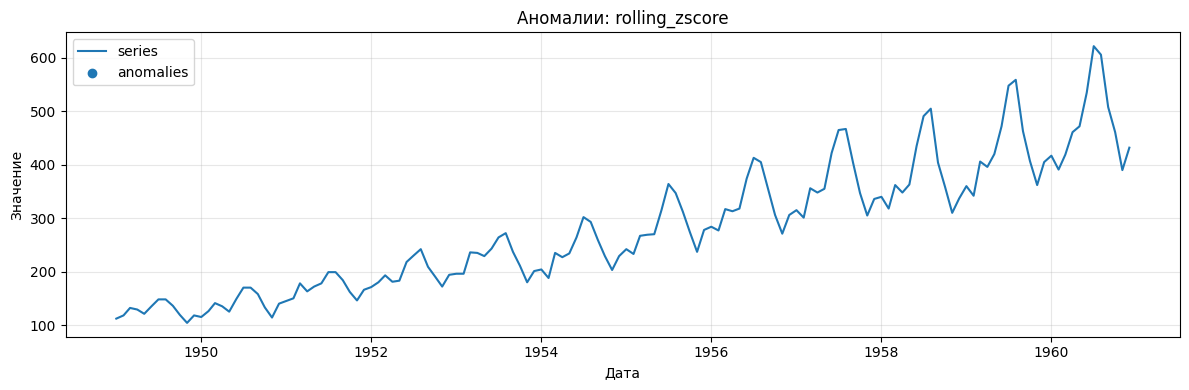

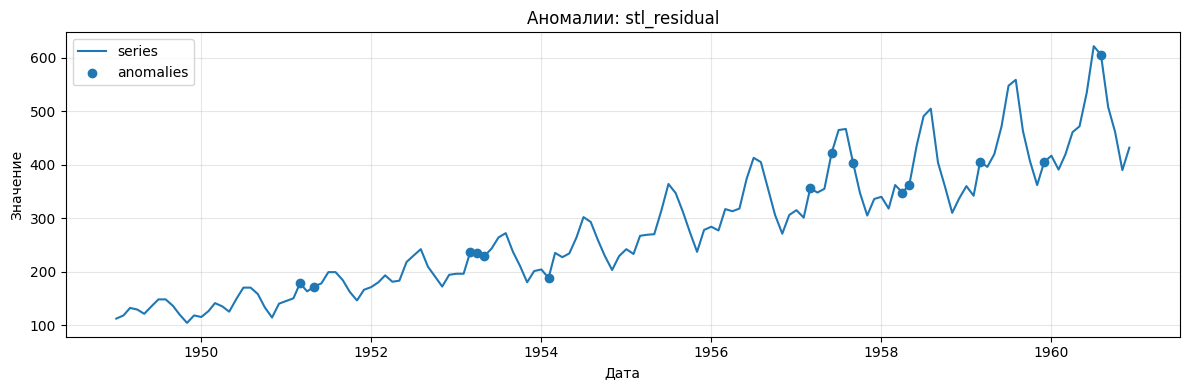

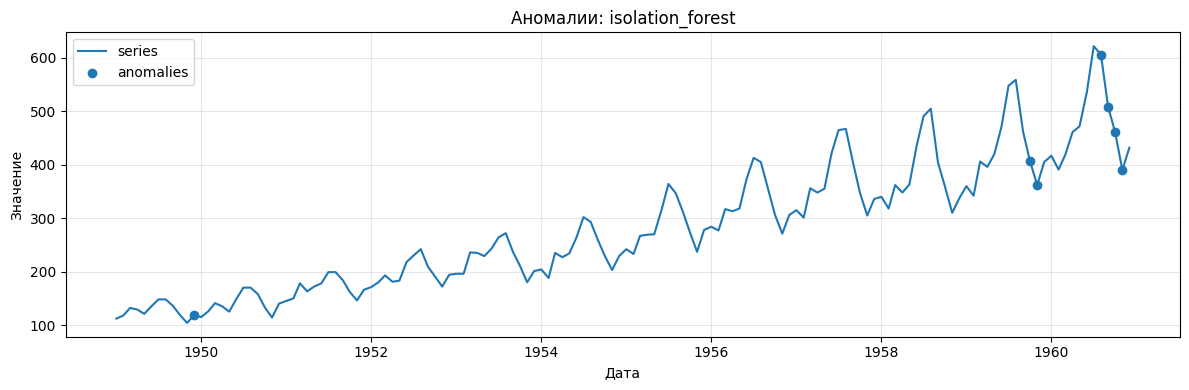

In [4]:
for method_name, result in methods.items():
    anomalies = result[result['is_anomaly']]

    plt.figure(figsize=(12, 4))
    plt.plot(series.index, series.values, label='series')
    plt.scatter(anomalies.index, anomalies['y'], label='anomalies', zorder=3)
    plt.title(f'Аномалии: {method_name}')
    plt.xlabel('Дата')
    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'anomalies_{method_name}.png', dpi=150)
    plt.show()

На графике `rolling_zscore` аномальные точки отсутствуют. Для данного ряда это ожидаемо: пассажиропоток имеет выраженный восходящий тренд и сезонность, а локальные отклонения не выглядят достаточно резкими относительно соседних значений.

Метод `stl_residual` выделяет больше точек, особенно в периоды усиления сезонных пиков и ускорения роста ряда. Это не обязательно ошибки в данных. Скорее, это месяцы, в которых фактическое значение сильнее отклоняется от восстановленной структуры «тренд + сезонность».

`IsolationForest` выделяет меньше точек и в основном обращает внимание на наиболее нетипичные уровни ряда, включая экстремальные значения в конце периода. Такой результат полезен как дополнительная проверка, но его нужно интерпретировать осторожно: модель может считать нетипичными просто самые высокие значения, потому что ряд растет во времени.

Общий вывод по визуализации: явных грубых выбросов, которые нужно автоматически удалить, не видно. Найденные точки лучше рассматривать как кандидаты на ручную проверку или как дополнительный бинарный признак `is_anomaly` при последующем моделировании.

## Итоговый вывод

В ноутбуке были проверены три подхода к поиску аномалий во временном ряду авиапассажиров: `rolling z-score`, `STL residual anomalies` и `IsolationForest`.

`Rolling z-score` оказался самым консервативным методом и не обнаружил аномалий. Для данного ряда это логично, так как основные изменения объясняются трендом и регулярной сезонностью.

`STL residual anomalies` оказался наиболее чувствительным и выделил 14 точек. Этот подход лучше подходит для сезонного временного ряда, потому что сначала отделяет сезонную структуру, а затем ищет отклонения в остатках. При этом найденные точки не следует автоматически считать ошибками данных.

`IsolationForest` нашел 7 точек и может использоваться как дополнительный ML-инструмент для поиска нетипичных комбинаций значений. Однако для растущего временного ряда метод чувствителен к масштабу и может помечать как аномалии самые высокие значения в конце периода.

Финальный вывод: в данных не обнаружено очевидных грубых выбросов, которые нужно удалять перед прогнозированием. Оптимальная стратегия - сохранить исходный ряд без удаления наблюдений, а найденные аномальные точки использовать для ручной проверки, анализа остатков и, при необходимости, как дополнительный признак в дальнейших моделях.